<a href="https://colab.research.google.com/github/risagon/learning/blob/main/Mask2Former_Cat_Dog_5Fold_PQ_drive_resume_or_new.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 猫・犬・背景 Mask2Former — 200枚・5-fold・instance PQ
すべてのクラス・関数はこのNotebook内で定義します。外部Pythonファイルを生成しません。
PyTorch / Transformers 5.16.1を用いた既存のColab GPU環境で上から実行してください。
COCOのデータ準備セルを含みます。学習は最後の「5-fold実行」セルから開始します。


## 実験条件
- 0=背景、1=猫、2=犬。猫犬は個体ごと、背景は画像内で統合。void/crowdは学習から除外。
- 猫または犬を含み、人・他のCOCO動物を含まない画像をannotationで選別します。家具等は背景。`exclude_people` / `require_both`で変更可能。
- train2017から**ちょうど200枚**を選び、5-fold（各160枚学習／40枚hold-out validation）に分割します。猫のみ／犬のみ／両方の比率をできるだけ保ちます。
- 同一画像は自身を評価するfoldでは学習に使いません。各画像は5-foldを通じて1度だけhold-outになります。
- 各foldでSwinだけpretrained、Mask2Former本体はrandom initialization。optimizerも新しく作り、fold間で重みを引き継ぎません。
- FP32、一定学習率、各fold30epoch。5モデルを順番に学習するため、単一モデルより計算時間・保存容量が増えます。
- 各epochはhold-out40枚でloss・IoU/Dice・猫犬PQを評価。**bestはhold-out validation lossで選択**します。
- 各foldのbestを、独立したval2017（既定50枚）で評価します。val2017を学習やbest選択に使いません。5foldで同じval2017画像を使います。
- 猫犬別のPQ/SQ/RQは原画像サイズで測定。IoU/Diceは従来どおりリサイズ後のクラス領域指標です。PQはinstance APではありません。
- PQは同一カテゴリでIoU > 0.5を1対1対応とし、void補正と同カテゴリcrowdによるFP除外を実施します。背景PQは計算しません。
- 通常閾値(.5/.5)と低閾値(.1/.1)を別記録。主評価は通常閾値です。外部validationの結果を見て設定を選び直す場合は独立testが別途必要です。
- 5foldの平均・標本標準偏差、および200枚のhold-out TP/FP/FNを合算した猫犬別PQを保存します。hold-outのbest選択と評価は同じ40枚なので、独立val2017の結果も併記します。
- [COCO panoptic評価の定義](https://github.com/cocodataset/panopticapi/blob/master/panopticapi/evaluation.py)に沿った、選別した猫犬画像のPQです。COCO公式ベンチマークのスコアではありません。


In [ ]:
from __future__ import annotations
import csv
import json
import random
import logging
import time
import gc
from pathlib import Path
from datetime import datetime
from dataclasses import dataclass, asdict, replace
import numpy as np
import torch
import transformers
from torch.utils.data import DataLoader
from PIL import Image
from IPython.display import display

print('PyTorch:', torch.__version__, 'Transformers:', transformers.__version__)
print('CUDA:', torch.cuda.is_available())
if transformers.__version__ != '5.16.1':
    print('注意: 損失フックの検証済みバージョンは Transformers 5.16.1 です。')

@dataclass
class RunConfig:
    data_dir: str = '/content/mask2former_swin_coco/data/coco'
    output_dir: str = ''
    train_ids: tuple[int, ...] | None = None
    max_train_samples: int | None = 200
    exclude_people: bool = True
    require_both: bool = False
    eval_split: str = 'val2017'
    eval_label: str = 'validation'
    save_external_visualizations: bool = True
    visualization_limit: int = 10
    eval_ids: tuple[int, ...] | None = None
    max_eval_samples: int | None = 50
    epochs: int = 30
    image_size: int = 384
    batch_size: int = 1
    backbone_lr: float = 1e-5
    learning_rate: float = 1e-4
    weight_decay: float = .05
    max_grad_norm: float = 1.0
    freeze_backbone: bool = False
    seed: int = 42
    device: str = 'auto'
    save_every: int = 5
    resume: str | None = None  # このNotebookが保存したcheckpointを指定

CFG = RunConfig()


PyTorch: 2.11.0+cu128 Transformers: 5.16.1
CUDA: True


## 1. 再現性・COCO Dataset・画像前処理


In [ ]:
from __future__ import annotations

import argparse
import json
import logging
import random
from pathlib import Path

import numpy as np
import torch
import yaml




def setup(seed: int, device_name: str = 'auto', num_threads: int = 4) -> torch.device:
    logging.basicConfig(level=logging.INFO, format='%(asctime)s %(levelname)s %(message)s')
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.set_num_threads(num_threads)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.benchmark = False
    torch.backends.cudnn.deterministic = True
    if device_name == 'auto':
        device_name = 'cuda' if torch.cuda.is_available() else 'mps' if torch.backends.mps.is_available() else 'cpu'
    device = torch.device(device_name)
    logging.info('Device: %s | PyTorch: %s', device, torch.__version__)
    return device


def seed_worker(worker_id: int) -> None:
    seed = torch.initial_seed() % 2**32
    random.seed(seed)
    np.random.seed(seed)


def to_device(batch: dict, device: torch.device) -> dict:
    return {k: [x.to(device) for x in v] if isinstance(v, list) else v.to(device) for k, v in batch.items()}


def write_json(path: Path, value: dict) -> None:
    path.write_text(json.dumps(value, indent=2, ensure_ascii=False, default=str), encoding='utf-8')


def rng_state() -> dict:
    state = {'python': random.getstate(), 'numpy': np.random.get_state(), 'torch': torch.get_rng_state()}
    if torch.cuda.is_available():
        state['cuda'] = torch.cuda.get_rng_state_all()
    return state


def restore_rng(state: dict) -> None:
    random.setstate(state['python'])
    np.random.set_state(state['numpy'])
    torch.set_rng_state(state['torch'])
    if 'cuda' in state and torch.cuda.is_available():
        torch.cuda.set_rng_state_all(state['cuda'])


In [ ]:
"""Decode RGB segment IDs; retain distinct instances and contiguous semantics."""
from __future__ import annotations

import json
from pathlib import Path
from typing import Any

import numpy as np
from PIL import Image
from torch.utils.data import Dataset


ANIMAL_CATEGORIES = {'bird', 'cat', 'dog', 'horse', 'sheep', 'cow',
                     'elephant', 'bear', 'zebra', 'giraffe'}

def make_mapping(categories: list[dict]) -> dict:
    categories = sorted(categories, key=lambda c: c['id'])
    if not {'cat', 'dog'}.issubset({c['name'] for c in categories}):
        raise ValueError('COCO cat/dog categories are missing')
    groups = {'0': [], '1': [], '2': []}
    forward = {}
    for category in categories:
        label = {'cat': 1, 'dog': 2}.get(category['name'], 0)
        forward[str(category['id'])] = label
        groups[str(label)].append(category['id'])
    return {
        'task': 'cat_dog_instances_and_background_stuff_v1',
        'category_id_to_contiguous_id': forward,
        'contiguous_id_to_category_ids': groups,
        'id2label': {'0': 'background', '1': 'cat', '2': 'dog'},
        'label2id': {'background': 0, 'cat': 1, 'dog': 2},
        'isthing': {'0': False, '1': True, '2': True},
        'categories': categories,
        'void_crowd_policy': 'ignored_not_background',
        'background_policy': 'one_union_mask_per_image',
    }




def rgb_to_id(rgb: np.ndarray) -> np.ndarray:
    rgb = np.asarray(rgb, dtype=np.int64)
    return rgb[..., 0] + 256 * rgb[..., 1] + 65536 * rgb[..., 2]


def convert_annotation(rgb: np.ndarray, segments: list[dict], mapping: dict) -> tuple[np.ndarray, dict[int, int]]:
    ids = rgb_to_id(rgb)
    segmentation = np.zeros(ids.shape, dtype=np.int64)
    instances: dict[int, int] = {}
    background = np.zeros(ids.shape, dtype=bool)
    # Segment ID 0 = ignored void/crowd. Semantic class 0 = supervised background.
    # Different positive segment IDs preserve individual cat/dog instances,
    # including two animals that originally belonged to different COCO categories.
    for segment in segments:
        if segment.get('iscrowd', 0):
            continue
        pixels = ids == segment['id']
        if not pixels.any():
            continue
        semantic = mapping['category_id_to_contiguous_id'][str(segment['category_id'])]
        if semantic == 0:
            background |= pixels
        else:
            instance = len(instances) + 1
            segmentation[pixels] = instance
            instances[instance] = semantic
    # Merge all supervised background pixels (including people) into one stuff target.
    if background.any():
        instance = len(instances) + 1
        segmentation[background] = instance
        instances[instance] = 0
    return segmentation, instances



class CocoPanopticDataset(Dataset):
    def __init__(self, root: str | Path, split: str, max_samples: int | None = None,
                 mapping: dict | None = None) -> None:
        self.root, self.split = Path(root), split
        path = self.root / 'annotations' / f'panoptic_{split}.json'
        if not path.exists():
            raise FileNotFoundError(f'COCO annotation missing: {path}. Run the COCO data preparation cell first.')
        data = json.loads(path.read_text(encoding='utf-8'))
        own_mapping = make_mapping(data['categories'])
        if mapping is not None and own_mapping != mapping:
            raise ValueError('Dataset categories differ from training/checkpoint label mapping')
        self.mapping = mapping or own_mapping
        images = {im['id']: im for im in data['images']}
        self.records = [(images[a['image_id']], a) for a in sorted(data['annotations'], key=lambda a: a['image_id'])]
        if max_samples is not None:
            if max_samples < 1:
                raise ValueError('max_samples must be positive or omitted')
            self.records = self.records[:max_samples]
        if not self.records:
            raise ValueError(f'No samples in {path}')

    def __len__(self) -> int:
        return len(self.records)

    def __getitem__(self, index: int) -> dict[str, Any]:
        im, ann = self.records[index]
        image_path = self.root / self.split / im['file_name']
        mask_path = self.root / f'panoptic_{self.split}' / ann['file_name']
        if not mask_path.exists():
            mask_path = self.root / 'annotations' / f'panoptic_{self.split}' / ann['file_name']
        with Image.open(image_path) as source:
            image = source.convert('RGB')
        with Image.open(mask_path) as source:
            rgb = np.array(source.convert('RGB'))
        if rgb.shape[:2] != (image.height, image.width):
            raise ValueError(f'Image/annotation size mismatch: {image_path}')
        segmentation, instances = convert_annotation(rgb, ann['segments_info'], self.mapping)
        return {'image': image, 'segmentation_map': segmentation,
                'instance_id_to_semantic_id': instances, 'image_id': im['id']}


In [ ]:
from __future__ import annotations

import numpy as np
import torch
from transformers import Mask2FormerImageProcessor


def build_processor(image_size: int) -> Mask2FormerImageProcessor:
    if image_size < 32 or image_size % 32:
        raise ValueError('image_size must be a positive multiple of 32, at least 32')
    # Fixed square resize keeps variable COCO sizes batchable; aspect ratio is distorted.
    return Mask2FormerImageProcessor(
        do_resize=True, size={'height': image_size, 'width': image_size},
        do_rescale=True, rescale_factor=1 / 255, do_normalize=True,
        image_mean=[0.485, 0.456, 0.406], image_std=[0.229, 0.224, 0.225],
        size_divisor=32, ignore_index=0, do_reduce_labels=False,
    )


class PanopticCollator:
    def __init__(self, processor: Mask2FormerImageProcessor) -> None:
        self.processor = processor

    def __call__(self, samples: list[dict]) -> dict:
        empty = [not s['instance_id_to_semantic_id'] for s in samples]
        # The current fast processor cannot stack an empty list of binary masks.
        # Use a temporary preprocessing-only mask, then replace it with zero targets.
        batch = dict(self.processor(
            images=[s['image'] for s in samples],
            segmentation_maps=[np.ones_like(s['segmentation_map']) if e else s['segmentation_map']
                               for s, e in zip(samples, empty)],
            instance_id_to_semantic_id=[{1: 0} if e else s['instance_id_to_semantic_id']
                                       for s, e in zip(samples, empty)],
            return_tensors='pt',
        ))
        for i, is_empty in enumerate(empty):
            if is_empty:
                batch['mask_labels'][i] = batch['mask_labels'][i][:0]
                batch['class_labels'][i] = torch.empty(0, dtype=torch.long)
        return batch


## 2. モデル定義
事前学習済み重みはSwin-Tinyのみです。Mask2Former本体をrandom initializationした後、同じSwin構成で作られた内部backboneへImageNet事前学習重みを厳密にコピーし、全backbone parameterを照合します。分類headは使用しません。
`hidden_states_norms.stage*` は分類checkpointに存在しない出力用LayerNormのため、Transformersが新規初期化します（LOAD REPORTのMISSING表示は正常です）。


In [ ]:
from __future__ import annotations

import hashlib
import logging
from pathlib import Path
import torch
from transformers import AutoBackbone, Mask2FormerConfig, Mask2FormerForUniversalSegmentation, SwinConfig

BACKBONE = 'microsoft/swin-tiny-patch4-window7-224'
STAGES = ['stage1', 'stage2', 'stage3', 'stage4']
LOGGER = logging.getLogger(__name__)

DEBUG_PRETRAINED_LOADING = True


def analyze_pretrained_loading(
    model: Mask2FormerForUniversalSegmentation,
    loading_info: dict,
    checkpoint_name: str,
    num_labels: int,
    output_dir: str | Path | None = None
) -> str:
    """Analyze loaded weights and classify parameters as PRETRAINED or RANDOM_OR_REINITIALIZED."""
    # 1. Standardize loading info lists
    missing_keys = loading_info.get('missing_keys', [])
    unexpected_keys = loading_info.get('unexpected_keys', [])
    mismatched_keys_raw = loading_info.get('mismatched_keys', [])
    error_msgs = loading_info.get('error_msgs', [])

    # Handle mismatched_keys variation robustly
    mismatched_keys = []
    for item in mismatched_keys_raw:
        if isinstance(item, tuple):
            mismatched_keys.append(item[0])
        else:
            mismatched_keys.append(str(item))

    reinit_indicators = set(missing_keys) | set(mismatched_keys)

    # 2. Setup modules division
    module_categories = {
        'Swin backbone': 'model.pixel_level_module.encoder',
        'Pixel decoder': 'model.pixel_level_module.decoder',
        'Transformer decoder': 'model.transformer_module.decoder',
        'Query embeddings': 'model.transformer_module.queries_embed',
        'Mask predictor': 'model.transformer_module.predictor.mask_embed',
        'Class predictor': 'model.transformer_module.predictor.class_predictor'
    }

    report_lines = []
    report_lines.append("=" * 60)
    report_lines.append(f"Pretrained Weight Loading Diagnostics Report for {checkpoint_name}")
    report_lines.append(f"Target Classes (num_labels): {num_labels}")
    report_lines.append("=" * 60 + "\n")

    for category, keys in [('Missing keys', missing_keys), ('Unexpected keys', unexpected_keys),
                           ('Mismatched keys', mismatched_keys), ('Errors', error_msgs)]:
        report_lines.append("=" * 60)
        report_lines.append(category)
        report_lines.append("=" * 60)
        if keys:
            for k in keys:
                report_lines.append(f" - {k}")
        else:
            report_lines.append(" (None)")
        report_lines.append("")

    report_lines.append("=" * 60)
    report_lines.append("Parameter-Level Loading State Classification")
    report_lines.append("=" * 60)

    all_params = list(model.named_parameters())
    classified_params = []

    for name, param in all_params:
        is_reinit = False
        # Check if the param name starts with or matches any missing or mismatched keys
        if any(name == r_key or name.startswith(r_key + '.') for r_key in reinit_indicators):
            is_reinit = True

        status = "RANDOM_OR_REINITIALIZED" if is_reinit else "PRETRAINED"
        shape_str = str(list(param.shape))
        classified_params.append((status, name, param.numel(), shape_str))
        report_lines.append(f"{status:<25} {name:<70} shape={shape_str}")

    report_lines.append("\n" + "=" * 60)
    report_lines.append("Module-Level Weight Aggregation Analysis")
    report_lines.append("=" * 60)
    report_lines.append(f"{'Module':<25} {'Tensor Count':<15} {'Total Params':<15} {'Pretrained':<15} {'Random':<10} {'Pretrained %':<12}")
    report_lines.append("-" * 95)

    agg_stats = {}
    assigned_names = set()
    for mod_name, prefix in module_categories.items():
        agg_stats[mod_name] = {'tensors': 0, 'total_numel': 0, 'pretrained_numel': 0, 'random_numel': 0}
        for status, name, numel, _ in classified_params:
            if name.startswith(prefix):
                agg_stats[mod_name]['tensors'] += 1
                agg_stats[mod_name]['total_numel'] += numel
                if status == 'PRETRAINED':
                    agg_stats[mod_name]['pretrained_numel'] += numel
                else:
                    agg_stats[mod_name]['random_numel'] += numel
                assigned_names.add(name)

    # Catch-all class for other parts
    other_stats = {'tensors': 0, 'total_numel': 0, 'pretrained_numel': 0, 'random_numel': 0}
    for status, name, numel, _ in classified_params:
        if name not in assigned_names:
            other_stats['tensors'] += 1
            other_stats['total_numel'] += numel
            if status == 'PRETRAINED':
                other_stats['pretrained_numel'] += numel
            else:
                other_stats['random_numel'] += numel
    agg_stats['Other Components'] = other_stats

    for mod_name, stat in agg_stats.items():
        pct = (stat['pretrained_numel'] / stat['total_numel'] * 100) if stat['total_numel'] > 0 else 0.0
        report_lines.append(f"{mod_name:<25} {stat['tensors']:<15d} {stat['total_numel']:<15,d} {stat['pretrained_numel']:<15,d} {stat['random_numel']:<10,d} {pct:<12.1f}")

    tot_tensors = len(classified_params)
    tot_numel = sum(p[2] for p in classified_params)
    tot_pretrained = sum(p[2] for p in classified_params if p[0] == 'PRETRAINED')
    tot_random = sum(p[2] for p in classified_params if p[0] == 'RANDOM_OR_REINITIALIZED')
    tot_pct = (tot_pretrained / tot_numel * 100) if tot_numel > 0 else 0.0

    report_lines.append("-" * 95)
    report_lines.append(f"{'TOTAL MODEL':<25} {tot_tensors:<15d} {tot_numel:<15,d} {tot_pretrained:<15,d} {tot_random:<10,d} {tot_pct:<12.1f}")

    report_str = "\n".join(report_lines)
    if DEBUG_PRETRAINED_LOADING:
        print(report_str, flush=True)

    if output_dir:
        out_p = Path(output_dir)
        out_p.mkdir(parents=True, exist_ok=True)
        (out_p / 'pretrained_loading_report.txt').write_text(report_str, encoding='utf-8')

    return report_str


def verify_backbone(model: Mask2FormerForUniversalSegmentation, reference: torch.nn.Module) -> dict:
    actual = dict(model.model.pixel_level_module.encoder.named_parameters())
    expected = dict(reference.named_parameters())
    if actual.keys() != expected.keys():
        raise RuntimeError('Pretrained Swin verification failed: parameter names differ')
    digest = hashlib.sha256()
    for name, value in expected.items():
        candidate = actual[name].detach().cpu()
        value = value.detach().cpu()
        # Relax the tolerance for floating-point comparison
        if candidate.shape != value.shape or not torch.allclose(candidate, value, rtol=1e-5, atol=1e-8):
            raise RuntimeError(f'Pretrained Swin verification failed: {name}')
        digest.update(name.encode())
        digest.update(candidate.contiguous().numpy().tobytes())
    result = {'status': 'PASS', 'parameter_tensors': len(actual), 'sha256': digest.hexdigest()}
    LOGGER.info('Pretrained Swin verification: PASS (%d parameter tensors)', len(actual))
    return result


def build_model(mapping: dict, freeze_backbone: bool = False, cache_dir: str | None = None,
                revision: str = 'main', output_dir: str | Path | None = None
                ) -> Mask2FormerForUniversalSegmentation:
    LOGGER.info('Loading pretrained Swin backbone only: %s', BACKBONE)

    # Load the ImageNet-pretrained feature extractor first. The classifier keys are
    # intentionally unused. Stage-output LayerNorms are absent from the classification
    # checkpoint and are initialized by Transformers, as reported by loading_info_bb.
    reference, loading_info_bb = AutoBackbone.from_pretrained(
        BACKBONE,
        out_features=STAGES,
        ignore_mismatched_sizes=True,
        cache_dir=cache_dir,
        revision=revision,
        output_loading_info=True,
    )

    # Build Mask2Former from configuration only: pixel decoder, transformer decoder,
    # queries, mask head, and class head all remain randomly initialized.
    backbone_config = SwinConfig.from_dict(reference.config.to_dict())
    backbone_config.out_features = STAGES
    config = Mask2FormerConfig(
        backbone_config=backbone_config,
        num_labels=len(mapping['id2label']),
        id2label={int(k): v for k, v in mapping['id2label'].items()},
        label2id=mapping['label2id'],
    )
    model = Mask2FormerForUniversalSegmentation(config)

    # Copy into the already-created internal backbone. This avoids comparing a
    # COCO-fine-tuned Mask2Former backbone with the original ImageNet checkpoint.
    incompatible = model.model.pixel_level_module.encoder.load_state_dict(
        reference.state_dict(), strict=True
    )
    if incompatible.missing_keys or incompatible.unexpected_keys:
        raise RuntimeError(
            'Pretrained Swin copy failed: '
            f'missing={incompatible.missing_keys}, unexpected={incompatible.unexpected_keys}'
        )

    model.backbone_verification = verify_backbone(model, reference)
    model.backbone_verification['source'] = BACKBONE
    model.backbone_verification['new_stage_output_norms'] = sorted(
        key for key in loading_info_bb.get('missing_keys', [])
        if key.startswith('hidden_states_norms.')
    )
    model.backbone_verification['unused_classification_keys'] = sorted(
        loading_info_bb.get('unexpected_keys', [])
    )
    model.config.backbone_source = BACKBONE
    model.config.backbone_revision = getattr(reference.config, '_commit_hash', None) or revision
    model.config.initialization_policy = 'pretrained_swin_only_random_mask2former'

    # The report marks every non-backbone tensor as random, matching the actual policy.
    random_keys = [
        name for name, _ in model.named_parameters()
        if not name.startswith('model.pixel_level_module.encoder.')
    ]
    analyze_pretrained_loading(
        model=model,
        loading_info={
            'missing_keys': random_keys,
            'unexpected_keys': loading_info_bb.get('unexpected_keys', []),
            'mismatched_keys': loading_info_bb.get('mismatched_keys', []),
            'error_msgs': loading_info_bb.get('error_msgs', []),
        },
        checkpoint_name=BACKBONE,
        num_labels=len(mapping['id2label']),
        output_dir=output_dir,
    )
    del reference

    model.model.pixel_level_module.encoder.requires_grad_(not freeze_backbone)
    return model


def load_checkpoint_model(path: str | Path) -> Mask2FormerForUniversalSegmentation:
    path = Path(path)
    if not path.is_dir() or not (path / 'model.safetensors').is_file():
        raise ValueError(f'Expected a locally trained checkpoint directory: {path}')
    return Mask2FormerForUniversalSegmentation.from_pretrained(path, local_files_only=True)


def parameter_groups(model: torch.nn.Module, backbone_lr: float, learning_rate: float) -> list[dict]:
    backbone = list(model.model.pixel_level_module.encoder.parameters())
    ids = {id(p) for p in backbone}
    return [
        {'params': [p for p in backbone if p.requires_grad], 'lr': backbone_lr, 'name': 'backbone'},
        {'params': [p for p in model.parameters() if id(p) not in ids and p.requires_grad],
         'lr': learning_rate, 'name': 'mask2former'},
    ]


def inspect_model(model: torch.nn.Module) -> None:
    total = sum(p.numel() for p in model.parameters())
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    backbone = sum(p.numel() for p in model.model.pixel_level_module.encoder.parameters())
    LOGGER.info('\n%s\nMask2Former configuration\n%s\n'
        'Mask2Former pretrained checkpoint: NOT USED (random initialization)\n'
        'Backbone pretrained checkpoint: %s\n'
        'Backbone pretrained: TRUE\nNumber of classes: %d\nTotal parameters: %.3f M\n'
        'Trainable parameters: %.3f M\nBackbone parameters: %.3f M\n'
        'Mask2Former parameters: %.3f M\nBackbone weight verification: %s\n%s',
        '=' * 48, '=' * 48, BACKBONE, model.config.num_labels,
        total / 1e6, trainable / 1e6, backbone / 1e6, (total - backbone) / 1e6,
        model.backbone_verification['status'], '=' * 48)

## 3. 損失と評価のログ
- 全体: 重みと補助層を含むCE / mask / Dice。和がtotal loss。
- クラス別: 最終層でGTに対応づけられたqueryの分類CE。no-objectは別行。クラス別mask損失ではありません。
- 領域: クラス別IoU・Dice、mIoU・平均Dice・画素正解率。
- semanticは閾値除外なし。panoptic_defaultはscore=.5/mask=.5、panoptic_lowはscore=.1/mask=.1。両者overlap=.8。
- void/crowd/paddingを除外。棄却予測はFNとして扱います。GTまたは予測があるクラスをmacro平均します。
- リサイズ後のカテゴリ領域の診断です。instanceの一致を測るCOCO公式PQ/SQ/RQではありません。

各epochのtrainと評価をprint。クラス別表は評価時に表示。全クラスはCSVに記録し、終了時にも最終結果をprintします。batchごとのprintはありません。


In [ ]:
"""Read-only loss instrumentation and resized-grid segmentation diagnostics.

No replacement loss, extra matching, or random sampling is used.
Per-category CE is the unweighted mean over final-layer matched queries;
unmatched queries are recorded separately as no-object. It is not a
per-category decomposition of the full auxiliary/weighted training loss.
"""
from __future__ import annotations

import csv
import logging
from pathlib import Path

import torch
import torch.nn.functional as F


class DiagnosticsLogger:
    def __init__(self, model, mapping: dict) -> None:
        self.model = model
        self.mapping = mapping
        self.classes = len(mapping['id2label'])
        self.original_loss_dict = model.get_loss_dict
        self.original_labels = model.criterion.loss_labels
        self.last_report = None
        self.reset()

        def capture_labels(class_queries_logits, class_labels, indices):
            if self.first_labels:
                self.first_labels = False
                with torch.no_grad():
                    logits = class_queries_logits.detach().float()
                    targets = torch.full(logits.shape[:2], self.classes,
                                         device=logits.device, dtype=torch.long)
                    for b, (src, dst) in enumerate(indices):
                        targets[b, src] = class_labels[b][dst]
                    ce = F.cross_entropy(logits.transpose(1, 2), targets, reduction='none')
                    ids = targets.flatten().cpu()
                    self.ce_sum += torch.bincount(ids, weights=ce.flatten().double().cpu(),
                                                 minlength=self.classes + 1)
                    self.ce_count += torch.bincount(ids, minlength=self.classes + 1)
            return self.original_labels(class_queries_logits, class_labels, indices)

        def capture_loss_dict(*args, **kwargs):
            self.first_labels = True
            losses = self.original_loss_dict(*args, **kwargs)
            logits = kwargs.get('class_queries_logits')
            if logits is None:
                logits = args[1]
            n = logits.shape[0]
            values = {k: float(v.detach()) for k, v in losses.items()}
            for name in self.loss_sums:
                self.loss_sums[name] += n * sum(v for k, v in values.items() if k.startswith(name))
            self.loss_images += n
            return losses

        model.criterion.loss_labels = capture_labels
        model.get_loss_dict = capture_loss_dict

    def close(self) -> None:
        self.model.get_loss_dict = self.original_loss_dict
        self.model.criterion.loss_labels = self.original_labels
        if self.last_report is not None:
            row, per_class, output_dir = self.last_report
            self.print_report(row, per_class, title='FINAL DIAGNOSTICS (last measured epoch)')
            print(f'CSV: {output_dir / "diagnostic_epoch_log.csv"}', flush=True)
            print(f'CSV: {output_dir / "diagnostic_class_log.csv"}', flush=True)

    @staticmethod
    def print_report(row: dict, per_class: list[dict], title: str = 'EPOCH DIAGNOSTICS') -> None:
        def number(value):
            return '-' if value is None else f'{value:.4f}'
        print(f'\n[{title}] epoch={row["epoch"]} split={row["split"]}', flush=True)
        print('  total={}  CE={}  mask={}  dice={}'.format(
            number(row['total_loss']), number(row['loss_cross_entropy_weighted_all_layers']),
            number(row['loss_mask_weighted_all_layers']), number(row['loss_dice_weighted_all_layers'])), flush=True)
        if row['metric_images']:
            for variant in ['semantic', 'panoptic_default', 'panoptic_low']:
                print('  {}: mIoU={} Dice={} accuracy={} coverage={} empty={}'.format(
                    variant, *[number(row[variant + '_' + metric]) for metric in
                    ['miou', 'mean_dice', 'pixel_accuracy', 'coverage', 'empty_image_rate']]), flush=True)
            print(f'  {"class":24s} {"queries":>7s} {"CE":>8s} {"semIoU":>8s} {"panIoU":>8s} {"lowIoU":>8s}', flush=True)
            for item in per_class:
                # Absent classes stay in CSV; print classes observed in GT or predictions.
                if not item['gt_assigned_query_count'] and item['semantic_iou'] is None and item['panoptic_low_iou'] is None:
                    continue
                print('  {:24s} {:7d} {:>8s} {:>8s} {:>8s} {:>8s}'.format(
                    item['class_name'], item['gt_assigned_query_count'],
                    *[number(item[key]) for key in ['classification_ce_unweighted_final_layer',
                      'semantic_iou', 'panoptic_default_iou', 'panoptic_low_iou']]), flush=True)

    def reset(self) -> None:
        self.first_labels = True
        self.ce_sum = torch.zeros(self.classes + 1, dtype=torch.float64)
        self.ce_count = torch.zeros(self.classes + 1, dtype=torch.int64)
        self.loss_sums = dict.fromkeys(['loss_cross_entropy', 'loss_mask', 'loss_dice'], 0.0)
        self.loss_images = 0
        # Extra prediction column denotes rejected/void predictions, counted as false negatives.
        self.confusion = {name: torch.zeros((self.classes, self.classes + 1), dtype=torch.int64)
                          for name in ['semantic', 'panoptic_default', 'panoptic_low']}
        self.metric_images = 0
        self.empty_images = dict.fromkeys(self.confusion, 0)

    @torch.no_grad()
    def update_metrics(self, outputs, batch: dict, processor) -> None:
        # Metrics use exactly the resized/padded target masks delivered to the model.
        # Void/crowd and padding are excluded using the target union and pixel_mask.
        sizes = [tuple(mask.shape[-2:]) for mask in batch['mask_labels']]
        semantic = processor.post_process_semantic_segmentation(outputs, target_sizes=sizes)
        stuff = {int(k) for k, value in self.mapping['isthing'].items() if not value}
        predictions = {'semantic': semantic}
        for name, threshold, mask_threshold in [('panoptic_default', .5, .5), ('panoptic_low', .1, .1)]:
            results = processor.post_process_panoptic_segmentation(
                outputs, threshold=threshold, mask_threshold=mask_threshold,
                overlap_mask_area_threshold=.8, label_ids_to_fuse=stuff, target_sizes=sizes)
            maps = []
            for result in results:
                labels = torch.full_like(result['segmentation'], self.classes, dtype=torch.long)
                for segment in result['segments_info']:
                    labels[result['segmentation'] == segment['id']] = segment['label_id']
                maps.append(labels)
            predictions[name] = maps
        for i, (masks, classes) in enumerate(zip(batch['mask_labels'], batch['class_labels'])):
            masks, classes = masks.detach().cpu(), classes.detach().cpu()
            truth = torch.full(sizes[i], -1, dtype=torch.long)
            assert not ((masks > .5).sum(0) > 1).any(), 'GT instance masks overlap'
            for mask, label in zip(masks, classes):
                truth[mask > .5] = label
            valid = (truth >= 0) & batch['pixel_mask'][i].detach().cpu().bool()
            for name, maps in predictions.items():
                prediction = maps[i].detach().long().cpu()
                self.empty_images[name] += int(not (prediction < self.classes).any())
                codes = truth[valid] * (self.classes + 1) + prediction[valid]
                self.confusion[name] += torch.bincount(
                    codes, minlength=self.classes * (self.classes + 1)).reshape(self.classes, self.classes + 1)
            self.metric_images += 1

    @staticmethod
    def scores(matrix: torch.Tensor) -> dict:
        matrix = matrix.double()
        count = matrix.shape[0]
        tp = matrix[:, :count].diag()
        gt = matrix.sum(1)
        pred = matrix[:, :count].sum(0)
        union = gt + pred - tp
        iou = torch.where(union > 0, tp / union, torch.nan)
        dice = torch.where(gt + pred > 0, 2 * tp / (gt + pred), torch.nan)
        total = gt.sum().item()
        return {'iou': iou, 'dice': dice, 'gt_pixels': gt,
                'miou': float(iou.nanmean()) if (union > 0).any() else None,
                'mean_dice': float(dice.nanmean()) if (union > 0).any() else None,
                'pixel_accuracy': tp.sum().item() / total if total else None,
                'coverage': matrix[:, :count].sum().item() / total if total else None}

    @staticmethod
    def append(path: Path, rows: list[dict]) -> None:
        if not rows:
            return
        path.parent.mkdir(parents=True, exist_ok=True)
        exists = path.exists() and path.stat().st_size > 0
        if exists:
            with path.open(encoding='utf-8', newline='') as stream:
                if next(csv.reader(stream)) != list(rows[0]):
                    raise ValueError(f'CSV schema differs: {path}')
        with path.open('a', newline='', encoding='utf-8') as stream:
            writer = csv.DictWriter(stream, fieldnames=list(rows[0]))
            if not exists:
                writer.writeheader()
            writer.writerows(rows)

    def write_epoch(self, output_dir: str | Path, epoch: int, split: str) -> dict:
        output_dir = Path(output_dir)
        row = {'epoch': epoch, 'split': split, 'loss_images': self.loss_images,
               'metric_images': self.metric_images}
        row.update({k + '_weighted_all_layers': v / self.loss_images if self.loss_images else None
                    for k, v in self.loss_sums.items()})
        row['total_loss'] = sum(self.loss_sums.values()) / self.loss_images if self.loss_images else None
        scores = {k: self.scores(v) for k, v in self.confusion.items()}
        for name, values in scores.items():
            for metric in ['miou', 'mean_dice', 'pixel_accuracy', 'coverage']:
                row[name + '_' + metric] = values[metric] if self.metric_images else None
            row[name + '_empty_image_rate'] = self.empty_images[name] / self.metric_images if self.metric_images else None
        self.append(output_dir / 'diagnostic_epoch_log.csv', [row])
        per_class = []
        for label in range(self.classes + 1):
            count = self.ce_count[label].item()
            item = {'epoch': epoch, 'split': split, 'class_id': label,
                    'category_ids': self.mapping['contiguous_id_to_category_ids'].get(str(label)),
                    'class_name': self.mapping['id2label'].get(str(label), '__no_object__'),
                    'gt_assigned_query_count': count,
                    'classification_ce_unweighted_final_layer': self.ce_sum[label].item() / count if count else None}
            for name, values in scores.items():
                for metric in ['iou', 'dice', 'gt_pixels']:
                    value = values[metric][label].item() if label < self.classes and self.metric_images else None
                    item[name + '_' + metric] = value if value is not None and value == value else None
            per_class.append(item)
        self.append(output_dir / 'diagnostic_class_log.csv', per_class)
        self.last_report = (row, per_class, output_dir)
        self.print_report(row, per_class)
        return row


## 4. 評価・checkpoint・学習関数（FP32・一定学習率）


In [ ]:
def choose_catdog_ids(data: dict, cfg, ids=None, limit=None) -> list[int]:
    """Filter annotations before selecting or downloading images. No image classifier is used."""
    category_ids = {c['name']: c['id'] for c in data['categories']}
    cat, dog = category_ids['cat'], category_ids['dog']
    forbidden = {category_ids[name] for name in ANIMAL_CATEGORIES - {'cat', 'dog'}}
    if cfg.exclude_people:
        forbidden.add(category_ids['person'])
    eligible = {}
    for ann in data['annotations']:
        segments = ann['segments_info']
        present = {s['category_id'] for s in segments}  # includes crowd for exclusion
        supervised = {s['category_id'] for s in segments
                      if not s.get('iscrowd', 0) and s.get('area', 1) > 0}
        pets = supervised & {cat, dog}
        if present & forbidden or not pets:
            continue
        if cfg.require_both and pets != {cat, dog}:
            continue
        eligible[ann['image_id']] = pets
    if ids is not None:
        if len(ids) != len(set(ids)):
            raise ValueError('Duplicate requested image IDs')
        invalid = set(ids) - eligible.keys()
        if invalid:
            raise ValueError(f'Images fail cat/dog selection or are missing: {sorted(invalid)}')
        return sorted(ids)
    if limit is not None and limit < 1:
        raise ValueError('Sample limit must be positive or None')
    # Deterministic round-robin selection avoids taking only cats or only dogs by ID order.
    rng = random.Random(cfg.seed)
    buckets = [[], [], []]  # cat-only, dog-only, both
    for image_id in sorted(eligible):
        pets = eligible[image_id]
        index = 2 if len(pets) == 2 else 0 if cat in pets else 1
        buckets[index].append(image_id)
    for bucket in buckets:
        rng.shuffle(bucket)
    selected = []
    while any(buckets) and (limit is None or len(selected) < limit):
        for bucket in buckets:
            if bucket and (limit is None or len(selected) < limit):
                selected.append(bucket.pop())
    if not selected:
        raise ValueError('No images satisfy cat/dog selection. Check the filters and full annotation JSON.')
    return sorted(selected)

def select_dataset(cfg, split, ids, mapping=None, limit=None):
    dataset = CocoPanopticDataset(cfg.data_dir, split, mapping=mapping)
    path = Path(cfg.data_dir) / 'annotations' / f'panoptic_{split}.json'
    data = json.loads(path.read_text(encoding='utf-8'))
    actual_limit = cfg.max_train_samples if split == 'train2017' and limit is None else limit
    wanted = set(choose_catdog_ids(data, cfg, ids, actual_limit))
    dataset.records = [(im, ann) for im, ann in dataset.records if im['id'] in wanted]
    if not dataset.records:
        raise ValueError('Selected dataset is empty')
    return dataset

def summarize_catdog_dataset(dataset, name):
    forward = dataset.mapping['category_id_to_contiguous_id']
    images = {'cat': 0, 'dog': 0, 'both': 0}
    instances = {'cat': 0, 'dog': 0}
    for _, ann in dataset.records:
        labels = [forward[str(s['category_id'])] for s in ann['segments_info']
                  if not s.get('iscrowd', 0) and s.get('area', 1) > 0]
        for label, word in [(1, 'cat'), (2, 'dog')]:
            images[word] += int(label in labels)
            instances[word] += labels.count(label)
        images['both'] += int(1 in labels and 2 in labels)
    print(f'{name}: {len(dataset)} images | images={images} | instances={instances}', flush=True)
    if not images['cat'] or not images['dog']:
        raise ValueError(f'{name}: both cat and dog examples are required in the selected dataset; increase sample limit or revise explicit IDs')


@torch.no_grad()
def evaluate_notebook(model, loader, device, processor, diagnostics):
    model.eval()
    total, count = 0.0, 0
    for batch in loader:
        batch = to_device(batch, device)
        outputs = model(**batch)
        if not torch.isfinite(outputs.loss):
            raise FloatingPointError('Non-finite evaluation loss')
        n = batch['pixel_values'].shape[0]
        total += float(outputs.loss) * n
        count += n
        diagnostics.update_metrics(outputs, batch, processor)
    if not count:
        raise ValueError('Evaluation loader is empty')
    return total / count

def save_notebook_checkpoint(path, model, processor, mapping, optimizer, scheduler,
                             epoch, best_loss, cfg, generator):
    path = Path(path)
    path.mkdir(parents=True, exist_ok=True)
    model.save_pretrained(path, safe_serialization=True)
    processor.save_pretrained(path)
    write_json(path / 'label_mapping.json', mapping)
    write_json(path / 'notebook_config.json', asdict(cfg))
    write_json(path / 'checkpoint_metadata.json', {'epoch': epoch, 'best_loss': best_loss})
    write_json(path / 'initialization_verification.json', model.backbone_verification)
    torch.save(dict(optimizer=optimizer.state_dict(), scheduler=scheduler.state_dict(),
                    epoch=epoch, best_loss=best_loss, rng=rng_state(),
                    generator=generator.get_state()), path / 'notebook_state.pt')

def trim_training_logs(output_dir: str | Path, checkpoint_epoch: int) -> None:
    """Drop rows newer than the restored checkpoint to avoid duplicate epochs."""
    output_dir = Path(output_dir)
    for path in output_dir.glob('*.csv'):
        try:
            with path.open(encoding='utf-8', newline='') as stream:
                rows = list(csv.DictReader(stream))
        except (OSError, csv.Error):
            continue
        if not rows or 'epoch' not in rows[0]:
            continue
        kept = []
        for row in rows:
            try:
                epoch = int(row['epoch'])
            except (TypeError, ValueError):
                kept.append(row)
                continue
            if epoch <= checkpoint_epoch:
                kept.append(row)
        if len(kept) == len(rows):
            continue
        with path.open('w', encoding='utf-8', newline='') as stream:
            writer = csv.DictWriter(stream, fieldnames=list(rows[0]))
            writer.writeheader()
            writer.writerows(kept)
        print(f'Trimmed {path.name} to checkpoint epoch {checkpoint_epoch}', flush=True)


def train_notebook(cfg: RunConfig) -> Path:
    if cfg.epochs < 1 or cfg.batch_size < 1 or cfg.save_every < 1:
        raise ValueError('epochs/batch_size/save_every must be positive')
    device = setup(cfg.seed, cfg.device)
    output = Path(cfg.output_dir) if cfg.output_dir else Path(cfg.data_dir).parent.parent / 'outputs' / ('catdog3_' + datetime.now().strftime('%Y%m%d_%H%M%S_%f'))
    cfg = replace(cfg, output_dir=str(output.resolve()))
    output = Path(cfg.output_dir)
    if output.exists() and any(output.iterdir()) and not cfg.resume:
        raise FileExistsError('出力先が空ではありません。新しいoutput_dirを指定してください。')
    train_data = select_dataset(cfg, 'train2017', cfg.train_ids)
    mapping = train_data.mapping
    print('Classes:', mapping['id2label'], flush=True)
    eval_data = select_dataset(cfg, cfg.eval_split, cfg.eval_ids, mapping, cfg.max_eval_samples)
    summarize_catdog_dataset(train_data, 'train')
    summarize_catdog_dataset(eval_data, 'evaluation')
    if cfg.eval_split == 'train2017' and ({im['id'] for im, _ in train_data.records} & {im['id'] for im, _ in eval_data.records}):
        raise ValueError('Evaluation images must not overlap training images')
    split_name = cfg.eval_label
    print(f'Train={len(train_data)} Eval={len(eval_data)} ({split_name}), FP32, constant LR', flush=True)
    start, best_loss = 0, float('inf')
    generator = torch.Generator().manual_seed(cfg.seed)
    if cfg.resume:
        checkpoint = Path(cfg.resume)
        required = ['model.safetensors', 'notebook_state.pt', 'notebook_config.json',
                    'label_mapping.json', 'initialization_verification.json']
        missing = [name for name in required if not (checkpoint / name).is_file()]
        if missing:
            raise FileNotFoundError(f'Incomplete checkpoint {checkpoint}: missing {missing}')
        old_cfg = json.loads((checkpoint / 'notebook_config.json').read_text(encoding='utf-8'))
        # output_dir is intentionally excluded so the whole experiment can be
        # copied from /content to Google Drive (or back) before resuming.
        for key in ['image_size', 'batch_size', 'train_ids', 'eval_ids', 'eval_split', 'max_eval_samples', 'freeze_backbone', 'backbone_lr', 'learning_rate', 'weight_decay', 'seed', 'max_train_samples', 'exclude_people', 'require_both', 'eval_label']:
            current = json.loads(json.dumps(asdict(cfg)))[key]
            if old_cfg[key] != current:
                raise ValueError(f'Resume requires original setting: {key}')
        if json.loads((checkpoint / 'label_mapping.json').read_text(encoding='utf-8')) != mapping:
            raise ValueError('Checkpoint label mapping differs')
        model = load_checkpoint_model(checkpoint)
        model.backbone_verification = json.loads(
            (checkpoint / 'initialization_verification.json').read_text(encoding='utf-8')
        )
        model.model.pixel_level_module.encoder.requires_grad_(not cfg.freeze_backbone)
        processor = Mask2FormerImageProcessor.from_pretrained(checkpoint, local_files_only=True)
        print(f'Resuming locally from: {checkpoint}', flush=True)
    else:
        model = build_model(mapping, cfg.freeze_backbone, output_dir=output)
        processor = build_processor(cfg.image_size)
    inspect_model(model)
    model = model.to(device).float()
    optimizer = torch.optim.AdamW(parameter_groups(model, cfg.backbone_lr, cfg.learning_rate), weight_decay=cfg.weight_decay)
    scheduler = torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda=lambda _: 1.0)
    if cfg.resume:
        state = torch.load(checkpoint / 'notebook_state.pt', map_location='cpu', weights_only=False)
        optimizer.load_state_dict(state['optimizer'])
        scheduler.load_state_dict(state['scheduler'])
        start, best_loss = state['epoch'], state['best_loss']
        restore_rng(state['rng'])
        generator.set_state(state['generator'])
        trim_training_logs(output, start)
        if cfg.epochs <= start:
            raise ValueError('epochs must exceed the resumed epoch')
        print(f'Restored epoch {start}; continuing with epoch {start + 1}/{cfg.epochs}', flush=True)
    output.mkdir(parents=True, exist_ok=True)
    write_json(output / 'run_config.json', asdict(cfg))
    write_json(output / 'selected_images.json', {'train': [im['id'] for im, _ in train_data.records], 'evaluation': [im['id'] for im, _ in eval_data.records], 'eval_split': cfg.eval_split, 'exclude_people': cfg.exclude_people, 'require_both': cfg.require_both})
    options = dict(batch_size=cfg.batch_size, num_workers=0, collate_fn=PanopticCollator(processor))
    train_loader = DataLoader(train_data, shuffle=True, generator=generator, **options)
    eval_loader = DataLoader(eval_data, shuffle=False, **options)
    diagnostics = DiagnosticsLogger(model, mapping)
    completed = False
    try:
        for epoch in range(start + 1, cfg.epochs + 1):
            began = time.monotonic()
            diagnostics.reset()
            model.train()
            if device.type == 'cuda':
                torch.cuda.reset_peak_memory_stats(device)
            total, count = 0.0, 0
            for batch in train_loader:
                batch = to_device(batch, device)
                optimizer.zero_grad(set_to_none=True)
                outputs = model(**batch)  # FP32: no autocast/scaler
                loss = outputs.loss
                if not torch.isfinite(loss):
                    raise FloatingPointError(f'Non-finite train loss at epoch {epoch}')
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), cfg.max_grad_norm, error_if_nonfinite=True)
                optimizer.step()
                n = batch['pixel_values'].shape[0]
                total += float(loss.detach()) * n
                count += n
            diagnostics.write_epoch(output, epoch, 'train')
            diagnostics.reset()
            cuda_devices = [device.index if device.index is not None else torch.cuda.current_device()] if device.type == 'cuda' else []
            with torch.random.fork_rng(devices=cuda_devices):
                eval_loss = evaluate_notebook(model, eval_loader, device, processor, diagnostics)
            diagnostics.write_epoch(output, epoch, split_name)
            compute_pq_dataset(model, processor, eval_data, device, output, epoch, split_name)
            improved = eval_loss < best_loss
            best_loss = min(best_loss, eval_loss)
            scheduler.step()  # multiplier=1: learning rate is constant
            args = (model, processor, mapping, optimizer, scheduler, epoch, best_loss, cfg, generator)
            if improved:
                save_notebook_checkpoint(output / 'best', *args)
            if epoch % cfg.save_every == 0:
                save_notebook_checkpoint(output / f'checkpoint_epoch_{epoch:03d}', *args)
            if epoch == cfg.epochs:
                save_notebook_checkpoint(output / 'final', *args)
            row = dict(epoch=epoch, train_loss=total/count, eval_loss=eval_loss, eval_split=split_name,
                       learning_rate_backbone=optimizer.param_groups[0]['lr'],
                       learning_rate_mask2former=optimizer.param_groups[1]['lr'],
                       gpu_memory_mb=torch.cuda.max_memory_allocated(device)/1024**2 if device.type == 'cuda' else 0,
                       elapsed_seconds=time.monotonic()-began)
            DiagnosticsLogger.append(output / 'training_log.csv', [row])
            save_notebook_checkpoint(output / 'last', *args)
            print('Epoch complete:', row, flush=True)
        completed = True
    finally:
        diagnostics.close()
        print('学習完了' if completed else '学習は中断または失敗しました。上の表は最後に測定した結果です。', flush=True)
        print('Output:', output, flush=True)
    return output


## 5. COCO取得・選別（まだ学習は開始しません）


### COCOデータ準備（新しいランタイムでも実行）
公式panoptic archive（約861 MB）を取得し、CFGで選んだ画像とマスクだけを展開します。追加Pythonファイルは生成しません。展開用ZIPを含め約2 GBの空き容量を確保してください。


In [ ]:
# 学習実行セルの前に実行。CFGとDatasetの定義セルは先に実行してください。
import json
import shutil
import time
import urllib.request
import zipfile
from pathlib import Path
from PIL import Image

COCO_BASE = "https://s3.amazonaws.com/images.cocodataset.org"

def download_coco_file(url, destination):
    destination = Path(destination)
    if destination.exists() and destination.stat().st_size > 0:
        return
    destination.parent.mkdir(parents=True, exist_ok=True)
    temporary = destination.with_suffix(destination.suffix + ".part")
    for attempt in range(3):
        try:
            print("Downloading:", destination.name, flush=True)
            with urllib.request.urlopen(url, timeout=120) as response, temporary.open("wb") as out:
                total = int(response.headers.get("Content-Length", 0))
                received, last_print = 0, time.monotonic()
                while chunk := response.read(1024 * 1024):
                    out.write(chunk)
                    received += len(chunk)
                    if time.monotonic() - last_print >= 5:
                        print(f"  {received / 1e6:.0f} / {total / 1e6:.0f} MB", flush=True)
                        last_print = time.monotonic()
                if total and received != total:
                    raise IOError("Incomplete download")
            temporary.replace(destination)
            return
        except (OSError, TimeoutError):
            if attempt == 2:
                raise
            time.sleep(2 ** attempt)

def prepare_coco_notebook(cfg, archive_dir=None):
    root = Path(cfg.data_dir)
    archives = Path(archive_dir) if archive_dir else root / "archives"
    archive = archives / "panoptic_annotations_trainval2017.zip"
    download_coco_file(f"{COCO_BASE}/annotations/{archive.name}", archive)
    requests = [("train2017", cfg.train_ids, cfg.max_train_samples),
                (cfg.eval_split, cfg.eval_ids, cfg.max_eval_samples)]
    with zipfile.ZipFile(archive) as outer:
        # 同じsplitの学習画像と評価画像をまとめて準備する。
        for split in sorted({item[0] for item in requests}):
            name = next(n for n in outer.namelist() if n.endswith(f"panoptic_{split}.json"))
            data = json.loads(outer.read(name))
            available = {ann["image_id"] for ann in data["annotations"]}
            wanted = set()
            for requested_split, ids, limit in requests:
                if requested_split == split:
                    selected = set(choose_catdog_ids(data, cfg, ids, limit))
                    if selected - available:
                        raise ValueError(f"Unknown image IDs: {sorted(selected - available)}")
                    wanted.update(selected)
            masks_zip = archives / f"panoptic_{split}.zip"
            if not masks_zip.exists():
                nested = next(n for n in outer.namelist() if n.endswith(masks_zip.name))
                temporary = masks_zip.with_suffix(".zip.part")
                print("Extracting:", masks_zip.name, flush=True)
                with outer.open(nested) as source, temporary.open("wb") as target:
                    shutil.copyfileobj(source, target)
                temporary.replace(masks_zip)
            mask_dir = root / f"panoptic_{split}"
            mask_dir.mkdir(parents=True, exist_ok=True)
            with zipfile.ZipFile(masks_zip) as masks:
                members = {Path(n).name: n for n in masks.namelist() if n.endswith(".png")}
                for ann in data["annotations"]:
                    if ann["image_id"] in wanted:
                        (mask_dir / ann["file_name"]).write_bytes(masks.read(members[ann["file_name"]]))
            for image in data["images"]:
                if image["id"] in wanted:
                    path = root / split / image["file_name"]
                    download_coco_file(f"{COCO_BASE}/{split}/{image['file_name']}", path)
                    with Image.open(path) as opened:
                        opened.verify()
            # 全カテゴリ・全JSONを保存。画像とPNGは選択したものだけ取得。
            annotation_dir = root / "annotations"
            annotation_dir.mkdir(parents=True, exist_ok=True)
            (annotation_dir / f"panoptic_{split}.json").write_text(json.dumps(data), encoding="utf-8")
            print(f"{split}: {len(wanted)} images ready", flush=True)
    for split, ids, limit in requests:
        dataset = select_dataset(cfg, split, ids, limit=limit)
        summarize_catdog_dataset(dataset, split)
        for index in range(len(dataset)):
            sample = dataset[index]
            print(f"Read OK: {split}/{sample['image_id']:012d}", flush=True)
    print("COCO準備完了。学習実行セルを実行できます。", flush=True)

prepare_coco_notebook(CFG)


Downloading: panoptic_annotations_trainval2017.zip
  264 / 861 MB
  522 / 861 MB
  580 / 861 MB
  600 / 861 MB
  622 / 861 MB
  639 / 861 MB
  649 / 861 MB
  660 / 861 MB
  671 / 861 MB
  683 / 861 MB
  689 / 861 MB
  699 / 861 MB
  711 / 861 MB
  718 / 861 MB
  731 / 861 MB
  771 / 861 MB
  825 / 861 MB
  842 / 861 MB
  858 / 861 MB
Extracting: panoptic_train2017.zip
Downloading: 000000183757.jpg
Downloading: 000000143824.jpg
Downloading: 000000341393.jpg
Downloading: 000000103806.jpg
Downloading: 000000553721.jpg
Downloading: 000000133251.jpg
Downloading: 000000435316.jpg
Downloading: 000000437119.jpg
Downloading: 000000180373.jpg
Downloading: 000000305142.jpg
Downloading: 000000552395.jpg
Downloading: 000000522909.jpg
Downloading: 000000201918.jpg
Downloading: 000000283471.jpg
Downloading: 000000315073.jpg
Downloading: 000000178939.jpg
Downloading: 000000306395.jpg
Downloading: 000000070493.jpg
Downloading: 000000572184.jpg
Downloading: 000000403421.jpg
Downloading: 000000016164.jpg

## 6. 保存済みcheckpointの評価・可視化関数


In [ ]:
from __future__ import annotations

from pathlib import Path

import numpy as np
from PIL import Image, ImageDraw


def palette(num_classes: int, seed: int = 42) -> np.ndarray:
    return np.random.default_rng(seed).integers(40, 240, (num_classes, 3), dtype=np.uint8)


def colorize(labels: np.ndarray, colors: np.ndarray) -> Image.Image:
    output = np.zeros((*labels.shape, 3), dtype=np.uint8)
    valid = labels >= 0
    output[valid] = colors[labels[valid]]
    return Image.fromarray(output)


def save_visualizations(sample: dict, prediction: dict, mapping: dict, output_dir: Path, seed: int = 42) -> None:
    output_dir.mkdir(parents=True, exist_ok=True)
    image = sample['image']
    gt = np.full((image.height, image.width), -1, dtype=np.int64)
    for instance, semantic in sample['instance_id_to_semantic_id'].items():
        gt[sample['segmentation_map'] == instance] = semantic
    predicted = np.full_like(gt, -1)
    segments = prediction['segmentation'].cpu().numpy()
    for segment in prediction['segments_info']:
        predicted[segments == segment['id']] = segment['label_id']
    colors = palette(len(mapping['id2label']), seed)
    prediction_image = colorize(predicted, colors)
    overlay = Image.blend(image, prediction_image, alpha=0.45)
    draw = ImageDraw.Draw(overlay)
    for label in np.unique(predicted[predicted >= 0]):
        yy, xx = np.where(predicted == label)
        position = (int(np.median(xx)), int(np.median(yy)))
        draw.text(position, mapping['id2label'][str(label)], fill='white', stroke_width=1, stroke_fill='black')
    for suffix, value in [('original', image), ('gt', colorize(gt, colors)),
                          ('prediction', prediction_image), ('overlay', overlay)]:
        value.save(output_dir / f"{sample['image_id']:012d}_{suffix}.png")


In [ ]:
def save_pet_instance_views(sample, prediction, output_dir, seed=42):
    """Colors and IDs distinguish cat/dog instances; background is gray, void is black."""
    output_dir = Path(output_dir)
    truth = sample['segmentation_map']
    pred = prediction['segmentation'].detach().cpu().numpy()
    groups = [
        ('gt_instances', truth, sample['instance_id_to_semantic_id']),
        ('prediction_instances', pred, {s['id']: s['label_id'] for s in prediction['segments_info']}),
    ]
    rendered = []
    for name, segments, labels in groups:
        canvas = np.zeros((*segments.shape, 3), dtype=np.uint8)
        colors = palette(sum(label in (1, 2) for label in labels.values()) + 1, seed)
        animals = []
        for segment, label in labels.items():
            mask = segments == segment
            if not mask.any():
                continue
            if label in (1, 2):
                animals.append((mask, label))
                canvas[mask] = colors[len(animals)]
            else:
                canvas[mask] = [110, 110, 110]
        image = Image.fromarray(canvas)
        draw = ImageDraw.Draw(image)
        for number, (mask, label) in enumerate(animals, start=1):
            ys, xs = np.where(mask)
            # Place ID on an actual mask pixel. Numbers are local, not matched across GT/pred.
            middle = len(xs) // 2
            draw.text((int(xs[middle]), int(ys[middle])), f"{'cat' if label == 1 else 'dog'} #{number}", fill='white', stroke_width=1, stroke_fill='black')
        image.save(output_dir / f"{sample['image_id']:012d}_{name}.png")
        rendered.append(image)
    width, height = sample['image'].size
    comparison = Image.new('RGB', (width * 3, height + 24), 'white')
    draw = ImageDraw.Draw(comparison)
    for column, (title, image) in enumerate(zip(['Original', 'GT cat/dog instances', 'Prediction cat/dog instances'], [sample['image'], *rendered])):
        comparison.paste(image, (column * width, 24))
        draw.text((column * width + 4, 4), title, fill='black')
    comparison.save(output_dir / f"{sample['image_id']:012d}_instance_comparison.png")


def evaluate_checkpoint_notebook(checkpoint, cfg, output_dir=None, epoch=None, visualize=True):
    gc.collect()  # Release models from a completed training call before reloading.
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
    checkpoint = Path(checkpoint)
    if epoch is None:
        meta = checkpoint / 'checkpoint_metadata.json'
        epoch = json.loads(meta.read_text())['epoch'] if meta.exists() else 0
    output = Path(output_dir) if output_dir else checkpoint.parent / ('evaluation_' + datetime.now().strftime('%Y%m%d_%H%M%S_%f'))
    device = setup(cfg.seed, cfg.device)
    mapping = json.loads((checkpoint / 'label_mapping.json').read_text(encoding='utf-8'))
    dataset = select_dataset(cfg, cfg.eval_split, cfg.eval_ids, mapping, cfg.max_eval_samples)
    processor = Mask2FormerImageProcessor.from_pretrained(checkpoint, local_files_only=True)
    model = load_checkpoint_model(checkpoint).to(device).float().eval()
    diagnostics = DiagnosticsLogger(model, mapping)
    try:
        loader = DataLoader(dataset, batch_size=cfg.batch_size, num_workers=0, collate_fn=PanopticCollator(processor))
        with torch.no_grad():
            evaluate_notebook(model, loader, device, processor, diagnostics)
            diagnostics.write_epoch(output, epoch, cfg.eval_label)
            compute_pq_dataset(model, processor, dataset, device, output, epoch, cfg.eval_label)
            if visualize:
                stuff = {int(k) for k, value in mapping['isthing'].items() if not value}
                for index in range(min(len(dataset), cfg.visualization_limit)):
                    sample = dataset[index]
                    inputs = processor(images=sample['image'], return_tensors='pt').to(device)
                    predictions = model(**inputs)
                    result = processor.post_process_panoptic_segmentation(
                        predictions, threshold=.1, mask_threshold=.1,
                        overlap_mask_area_threshold=.8, label_ids_to_fuse=stuff,
                        target_sizes=[(sample['image'].height, sample['image'].width)])[0]
                    save_visualizations(sample, result, mapping, output / 'mask_low', cfg.seed)
                    save_pet_instance_views(sample, result, output / 'mask_low', cfg.seed)
    finally:
        diagnostics.close()
        del model
        gc.collect()
        if device.type == 'cuda':
            torch.cuda.empty_cache()
    print('評価・画像の保存先:', output, flush=True)
    return output


## 7. 原画像サイズの猫犬PQ・5-foldの分割と集計関数


In [ ]:
class PetPanopticQuality:
    """Original-resolution cat/dog PQ, following COCO panoptic matching conventions.

    Reference: https://github.com/cocodataset/panopticapi/blob/master/panopticapi/evaluation.py
    Cat/dog remain COCO categories; background is not scored. Crowd retains its
    original category for FP suppression; it is NOT converted to generic void.
    This selected-subset metric is not a COCO leaderboard score or instance AP.
    """
    def __init__(self):
        self.stats = {label: dict(tp=0, fp=0, fn=0, sum_iou=0.0) for label in (1, 2)}
        self.images = 0

    def update(self, gt_ids, gt_segments, mapping, prediction):
        gt_ids = np.asarray(gt_ids)
        pred_ids = prediction['segmentation']
        if torch.is_tensor(pred_ids):
            pred_ids = pred_ids.detach().cpu().numpy()
        pred_ids = np.asarray(pred_ids)
        if gt_ids.shape != pred_ids.shape:
            raise ValueError('PQ requires original-resolution GT and predictions of the same shape')
        void = gt_ids == 0
        forward = mapping['category_id_to_contiguous_id']
        for label in (1, 2):
            normal = []
            crowd = np.zeros(gt_ids.shape, dtype=bool)
            for segment in gt_segments:
                if forward[str(segment['category_id'])] != label:
                    continue
                mask = gt_ids == segment['id']
                if not mask.any():
                    continue
                if segment.get('iscrowd', 0):
                    crowd |= mask
                else:
                    normal.append(mask)
            predicted = [pred_ids == segment['id'] for segment in prediction['segments_info']
                         if segment['label_id'] == label]
            predicted = [mask for mask in predicted if mask.any()]
            areas = [int(mask.sum()) for mask in predicted]
            void_overlap = [int((mask & void).sum()) for mask in predicted]
            matched_gt, matched_pred = set(), set()
            stat = self.stats[label]
            # With nonoverlapping panoptic masks, IoU > .5 matches are unique.
            for g, truth in enumerate(normal):
                for p, mask in enumerate(predicted):
                    intersection = int((truth & mask).sum())
                    union = int(truth.sum()) + areas[p] - intersection - void_overlap[p]
                    iou = intersection / union if union else 0.0
                    if iou > 0.5:
                        if g in matched_gt or p in matched_pred:
                            raise ValueError('Ambiguous panoptic matching: masks must not overlap')
                        matched_gt.add(g)
                        matched_pred.add(p)
                        stat['tp'] += 1
                        stat['sum_iou'] += iou
            stat['fn'] += len(normal) - len(matched_gt)
            for p, mask in enumerate(predicted):
                if p in matched_pred:
                    continue
                # Ignore unmatched predictions mostly covering void or SAME-class crowd.
                ignored = int((mask & (void | crowd)).sum())
                if ignored / areas[p] <= 0.5:
                    stat['fp'] += 1
        self.images += 1

    @staticmethod
    def score(stat):
        denominator = stat['tp'] + .5 * stat['fp'] + .5 * stat['fn']
        if denominator == 0:
            return dict(pq=None, sq=None, rq=None)
        return dict(pq=stat['sum_iou'] / denominator,
                    sq=stat['sum_iou'] / stat['tp'] if stat['tp'] else 0.0,
                    rq=stat['tp'] / denominator)

    def rows(self, epoch, split, variant):
        rows = []
        for label, stat in self.stats.items():
            rows.append(dict(epoch=epoch, split=split, variant=variant, images=self.images,
                             class_id=label, class_name='cat' if label == 1 else 'dog',
                             **stat, **self.score(stat)))
        summary = dict(epoch=epoch, split=split, variant=variant, images=self.images)
        for metric in ('pq', 'sq', 'rq'):
            values = [row[metric] for row in rows if row[metric] is not None]
            summary[metric] = sum(values) / len(values) if values else None
        return rows, summary


@torch.no_grad()
def compute_pq_dataset(model, processor, dataset, device, output_dir, epoch, split):
    model.eval()
    counters = {name: PetPanopticQuality() for name in ('panoptic_default', 'panoptic_low')}
    for index in range(len(dataset)):
        sample = dataset[index]
        _, annotation = dataset.records[index]
        path = dataset.root / f'panoptic_{dataset.split}' / annotation['file_name']
        if not path.exists():
            path = dataset.root / 'annotations' / f'panoptic_{dataset.split}' / annotation['file_name']
        with Image.open(path) as image:
            truth = rgb_to_id(np.array(image.convert('RGB')))
        # Original PNG and crowd metadata are used; training targets have discarded crowd.
        inputs = processor(images=sample['image'], return_tensors='pt').to(device)
        outputs = model(**inputs)
        for variant, threshold in [('panoptic_default', .5), ('panoptic_low', .1)]:
            result = processor.post_process_panoptic_segmentation(
                outputs, threshold=threshold, mask_threshold=threshold,
                overlap_mask_area_threshold=.8, label_ids_to_fuse={0},
                target_sizes=[truth.shape])[0]
            counters[variant].update(truth, annotation['segments_info'], dataset.mapping, result)
    class_rows, summaries = [], []
    for variant, counter in counters.items():
        rows, summary = counter.rows(epoch, split, variant)
        class_rows.extend(rows)
        summaries.append(summary)
        print(f'[INSTANCE PQ] epoch={epoch} split={split} {variant}', flush=True)
        for row in rows:
            def fmt(value):
                return '-' if value is None else f'{value:.4f}'
            print(f"  {row['class_name']:4s} PQ={fmt(row['pq'])} SQ={fmt(row['sq'])} RQ={fmt(row['rq'])} "
                  f"TP={row['tp']} FP={row['fp']} FN={row['fn']}", flush=True)
        print('  Cat/dog macro:', {key: summary[key] for key in ('pq', 'sq', 'rq')}, flush=True)
    output_dir = Path(output_dir)
    DiagnosticsLogger.append(output_dir / 'pq_class_log.csv', class_rows)
    DiagnosticsLogger.append(output_dir / 'pq_epoch_log.csv', summaries)
    return class_rows, summaries


def make_fivefold_plan(cfg):
    if cfg.max_train_samples != 200:
        raise ValueError('This experiment requires exactly 200 selected train images')
    if cfg.eval_split != 'val2017':
        raise ValueError('External validation must use val2017')
    pool = select_dataset(cfg, 'train2017', cfg.train_ids)
    external = select_dataset(cfg, 'val2017', cfg.eval_ids, pool.mapping, cfg.max_eval_samples)
    if len(pool) != 200:
        raise ValueError(f'Exactly 200 eligible images are required, found {len(pool)}')
    pool_ids = {image['id'] for image, _ in pool.records}
    external_ids = {image['id'] for image, _ in external.records}
    if pool_ids & external_ids:
        raise ValueError('train2017 and val2017 image IDs overlap')
    groups = {1: [], 2: [], 3: []}  # cat-only, dog-only, both
    forward = pool.mapping['category_id_to_contiguous_id']
    for image, ann in pool.records:
        labels = {forward[str(s['category_id'])] for s in ann['segments_info']
                  if not s.get('iscrowd', 0) and s.get('area', 1) > 0}
        key = int(1 in labels) + 2 * int(2 in labels)
        groups[key].append(image['id'])
    rng = random.Random(cfg.seed)
    holdouts = [[] for _ in range(5)]
    cursor = 0
    for key in (1, 2, 3):
        ids = sorted(groups[key])
        rng.shuffle(ids)
        for image_id in ids:
            holdouts[cursor % 5].append(image_id)
            cursor += 1
    folds = []
    for i, held_out in enumerate(holdouts, start=1):
        train_ids = sorted(pool_ids - set(held_out))
        if len(train_ids) != 160 or len(held_out) != 40:
            raise AssertionError('Expected 160 training and 40 held-out images')
        if set(train_ids) & set(held_out):
            raise AssertionError('Fold data leakage')
        # Also ensure each fold has both classes; fail before expensive training otherwise.
        for ids in (train_ids, held_out):
            if not any(x in ids for x in groups[1] + groups[3]) or not any(x in ids for x in groups[2] + groups[3]):
                raise ValueError('A fold lacks cat or dog examples; revise seed/selection')
        folds.append(dict(fold=i, train_ids=train_ids, validation_ids=sorted(held_out)))
    assert len({i for fold in folds for i in fold['validation_ids']}) == 200
    return dict(seed=cfg.seed, pool_ids=sorted(pool_ids), external_val_ids=sorted(external_ids), folds=folds)


def summarize_fivefold(root):
    root = Path(root)
    fold_rows, pooled = [], {}
    for fold in range(1, 6):
        folder = root / f'fold_{fold:02d}'
        for role in ('heldout_best', 'external_val2017'):
            with (folder / role / 'pq_epoch_log.csv').open(encoding='utf-8', newline='') as stream:
                rows = list(csv.DictReader(stream))
            for row in rows:
                fold_rows.append(dict(fold=fold, evaluation=role, **row))
        with (folder / 'heldout_best/pq_class_log.csv').open(encoding='utf-8', newline='') as stream:
            for row in csv.DictReader(stream):
                key = row['variant'], row['class_name']
                stat = pooled.setdefault(key, dict(tp=0, fp=0, fn=0, sum_iou=0.0))
                for value in stat:
                    stat[value] += float(row[value]) if value == 'sum_iou' else int(row[value])
    def overwrite_csv(path, rows):
        with path.open('w', encoding='utf-8', newline='') as stream:
            writer = csv.DictWriter(stream, fieldnames=list(rows[0]))
            writer.writeheader()
            writer.writerows(rows)
    overwrite_csv(root / 'fold_pq_summary.csv', fold_rows)
    means = []
    for role in ('heldout_best', 'external_val2017'):
        for variant in ('panoptic_default', 'panoptic_low'):
            row = dict(evaluation=role, variant=variant)
            subset = [r for r in fold_rows if r['evaluation'] == role and r['variant'] == variant]
            for metric in ('pq', 'sq', 'rq'):
                values = [float(r[metric]) for r in subset if r[metric] != '']
                row[metric + '_mean'] = float(np.mean(values)) if values else None
                row[metric + '_std'] = float(np.std(values, ddof=1)) if len(values) > 1 else None
            means.append(row)
    overwrite_csv(root / 'fivefold_mean_std.csv', means)
    oof = [dict(variant=variant, class_name=label, **stat, **PetPanopticQuality.score(stat))
           for (variant, label), stat in pooled.items()]
    overwrite_csv(root / 'oof_pq_by_class.csv', oof)
    print('\n5-FOLD COMPLETE: each model trained on 160 images; 40 held-out images per fold.', flush=True)
    for row in means:
        print(row, flush=True)
    print('Pooled held-out PQ (each of 200 images evaluated once):', oof, flush=True)
    print('Summary CSV folder:', root, flush=True)
    return means


def checkpoint_epoch(path):
    path = Path(path)
    required = ['model.safetensors', 'notebook_state.pt', 'notebook_config.json',
                'label_mapping.json', 'checkpoint_metadata.json',
                'initialization_verification.json']
    if any(not (path / name).is_file() for name in required):
        return None
    try:
        return int(json.loads(
            (path / 'checkpoint_metadata.json').read_text(encoding='utf-8')
        )['epoch'])
    except (OSError, KeyError, TypeError, ValueError, json.JSONDecodeError):
        return None


def latest_fold_checkpoint(folder):
    folder = Path(folder)
    if not folder.is_dir():
        return None, 0
    priorities = {'last': 4, 'final': 3, 'best': 2}
    candidates = []
    for path in folder.iterdir():
        if not path.is_dir():
            continue
        epoch = checkpoint_epoch(path)
        if epoch is None:
            continue
        priority = priorities.get(path.name, 1 if path.name.startswith('checkpoint_epoch_') else 0)
        candidates.append((epoch, priority, path))
    if not candidates:
        return None, 0
    epoch, _, path = max(candidates, key=lambda item: (item[0], item[1]))
    return path, epoch


def latest_fivefold_root(cfg):
    parent = Path(cfg.data_dir).parent.parent / 'outputs'
    candidates = [path for path in parent.glob('catdog_5fold_*')
                  if (path / 'fold_plan.json').is_file()]
    if not candidates:
        raise FileNotFoundError(f'No resumable five-fold experiment under {parent}')
    return max(candidates, key=lambda path: path.stat().st_mtime)


def evaluation_complete(path):
    path = Path(path)
    pq = path / 'pq_epoch_log.csv'
    if not pq.is_file():
        return False
    try:
        with pq.open(encoding='utf-8', newline='') as stream:
            variants = {row.get('variant') for row in csv.DictReader(stream)}
        return {'panoptic_default', 'panoptic_low'} <= variants
    except (OSError, csv.Error):
        return False


def preserve_partial_directory(path):
    path = Path(path)
    if not path.exists() or not any(path.iterdir()):
        return
    suffix = datetime.now().strftime('%Y%m%d_%H%M%S')
    destination = path.with_name(path.name + '_incomplete_' + suffix)
    counter = 1
    while destination.exists():
        destination = path.with_name(path.name + f'_incomplete_{suffix}_{counter}')
        counter += 1
    path.rename(destination)
    print(f'Preserved partial output as: {destination}', flush=True)


def run_fivefold(cfg, resume_root=None):
    if cfg.resume:
        raise ValueError('For five-fold recovery, pass resume_root to run_fivefold; cfg.resume is set per fold automatically')

    if resume_root is None:
        plan = make_fivefold_plan(cfg)
        root = Path(cfg.output_dir) if cfg.output_dir else Path(cfg.data_dir).parent.parent / 'outputs' / ('catdog_5fold_' + datetime.now().strftime('%Y%m%d_%H%M%S_%f'))
        if root.exists() and any(root.iterdir()):
            raise FileExistsError('Choose an empty output_dir for a new 5-fold experiment')
        root.mkdir(parents=True, exist_ok=True)
        write_json(root / 'fold_plan.json', plan)
        write_json(root / 'experiment_config.json', asdict(cfg))
        print('New experiment output:', root, flush=True)
    else:
        root = latest_fivefold_root(cfg) if str(resume_root).lower() == 'auto' else Path(resume_root)
        if not (root / 'fold_plan.json').is_file():
            raise FileNotFoundError(f'fold_plan.json is missing: {root}')
        plan = json.loads((root / 'fold_plan.json').read_text(encoding='utf-8'))
        if plan.get('seed') != cfg.seed:
            raise ValueError(f'Resume seed must remain {plan.get("seed")}, got {cfg.seed}')
        if len(plan.get('folds', [])) != 5:
            raise ValueError('Saved fold plan is invalid')
        print('Resuming experiment:', root, flush=True)

    for fold in plan['folds']:
        index = fold['fold']
        folder = root / f'fold_{index:02d}'
        completed = folder / 'completed_fold.json'
        if completed.is_file() and evaluation_complete(folder / 'heldout_best') and evaluation_complete(folder / 'external_val2017'):
            print(f'===== FOLD {index}/5 already complete: skipped =====', flush=True)
            continue

        print(f'\n===== FOLD {index}/5: train=160 validation=40 =====', flush=True)
        fold_cfg = replace(cfg, output_dir=str(folder),
                           train_ids=tuple(fold['train_ids']), max_train_samples=160,
                           eval_split='train2017', eval_ids=tuple(fold['validation_ids']),
                           max_eval_samples=40, eval_label='fold_validation', seed=cfg.seed + index)

        checkpoint, saved_epoch = latest_fold_checkpoint(folder)
        if checkpoint is not None and saved_epoch < cfg.epochs:
            print(f'Latest usable checkpoint: {checkpoint} (epoch {saved_epoch})', flush=True)
            fold_cfg = replace(fold_cfg, resume=str(checkpoint))
            gc.collect()
            if torch.cuda.is_available():
                torch.cuda.empty_cache()
            folder = train_notebook(fold_cfg)
        elif checkpoint is not None and saved_epoch >= cfg.epochs:
            print(f'Training already reached epoch {saved_epoch}; proceeding to evaluation.', flush=True)
        else:
            if folder.exists() and any(folder.iterdir()):
                preserve_partial_directory(folder)
            gc.collect()
            if torch.cuda.is_available():
                torch.cuda.empty_cache()
            folder = train_notebook(fold_cfg)

        best = folder / 'best'
        if not (best / 'model.safetensors').is_file():
            raise FileNotFoundError(f'Best checkpoint is missing after training: {best}')

        evaluation_cfg = replace(fold_cfg, resume=None)
        heldout = folder / 'heldout_best'
        if not evaluation_complete(heldout):
            preserve_partial_directory(heldout)
            evaluate_checkpoint_notebook(best, evaluation_cfg, output_dir=heldout, visualize=False)
        else:
            print('Held-out evaluation already complete: skipped', flush=True)

        external_cfg = replace(evaluation_cfg, eval_split='val2017',
                               eval_ids=tuple(plan['external_val_ids']),
                               max_eval_samples=len(plan['external_val_ids']),
                               eval_label='external_validation')
        external = folder / 'external_val2017'
        if not evaluation_complete(external):
            preserve_partial_directory(external)
            evaluate_checkpoint_notebook(best, external_cfg, output_dir=external,
                                         visualize=cfg.save_external_visualizations)
        else:
            print('External validation already complete: skipped', flush=True)

        write_json(completed, dict(fold=index, best=str(best)))

    summarize_fivefold(root)
    return root


## 8. Google Drive上のcheckpointから再開／なければ新規開始
Google Driveをマウントし、指定した実験フォルダに`fold_plan.json`があれば途中から再開します。見つからなければ、Google Drive上へ新しい5-fold実験を作成してepoch 1から開始します。
指定フォルダに別のファイルが残っている場合は上書きせず、日時付きの新しい実験フォルダへ保存します。その後のcheckpointはDrive側に保存されるため、Colabランタイムが切れても同じフォルダから再開できます。


In [ ]:
# Google Driveをマウント（初回は認証画面が表示されます）
from google.colab import drive
drive.mount('/content/drive')

# ★Google Drive上のoutputsフォルダに合わせて、この1行を変更します。
DRIVE_OUTPUTS = Path('/content/drive/MyDrive/
')
# 再開したい既存実験のフォルダ名。存在しない場合は新規学習になります。
EXPERIMENT_NAME = 'catdog_5fold_20260922_053909_542543'
RESUME_ROOT = DRIVE_OUTPUTS / EXPERIMENT_NAME
PLAN_FILE = RESUME_ROOT / 'fold_plan.json'

DRIVE_OUTPUTS.mkdir(parents=True, exist_ok=True)
if PLAN_FILE.is_file():
    print('保存済み実験を再開します:', RESUME_ROOT)
    CV_OUTPUT = run_fivefold(CFG, resume_root=RESUME_ROOT)
else:
    print('fold_plan.jsonが見つからないため、最初から学習します。')
    # 空でない同名フォルダは保護し、新しい日時付きフォルダを使います。
    if RESUME_ROOT.exists() and any(RESUME_ROOT.iterdir()):
        RESUME_ROOT = DRIVE_OUTPUTS / ('catdog_5fold_' + datetime.now().strftime('%Y%m%d_%H%M%S_%f'))
        print('既存ファイルを上書きしない新規保存先:', RESUME_ROOT)
    else:
        print('新規保存先:', RESUME_ROOT)
    NEW_CFG = replace(CFG, output_dir=str(RESUME_ROOT), resume=None)
    CV_OUTPUT = run_fivefold(NEW_CFG)


Mounted at /content/drive
fold_plan.jsonが見つからないため、最初から学習します。
新規保存先: /content/drive/MyDrive/mask2former_swin_coco/outputs/catdog_5fold_20260922_053909_542543
New experiment output: /content/drive/MyDrive/mask2former_swin_coco/outputs/catdog_5fold_20260922_053909_542543

===== FOLD 1/5: train=160 validation=40 =====
Classes: {'0': 'background', '1': 'cat', '2': 'dog'}
train: 160 images | images={'cat': 106, 'dog': 107, 'both': 53} | instances={'cat': 116, 'dog': 124}
evaluation: 40 images | images={'cat': 27, 'dog': 26, 'both': 13} | instances={'cat': 28, 'dog': 37}
Train=160 Eval=40 (fold_validation), FP32, constant LR


config.json:   0%|          | 0.00/71.8k [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  113MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/219 [00:00<?, ?it/s]

...

Epoch complete: {'epoch': 30, 'train_loss': 11.517482525110244, 'eval_loss': 52.141606736183164, 'eval_split': 'fold_validation', 'learning_rate_backbone': 1e-05, 'learning_rate_mask2former': 0.0001, 'gpu_memory_mb': 1586.43359375, 'elapsed_seconds': 74.48493524200057}

[FINAL DIAGNOSTICS (last measured epoch)] epoch=30 split=fold_validation
  total=52.1416  CE=4.1868  mask=34.8327  dice=13.1222
  semantic: mIoU=0.7923 Dice=0.8790 accuracy=0.9423 coverage=1.0000 empty=0.0000
  panoptic_default: mIoU=0.7912 Dice=0.8784 accuracy=0.9417 coverage=0.9993 empty=0.0000
  panoptic_low: mIoU=0.7922 Dice=0.8789 accuracy=0.9405 coverage=0.9957 empty=0.0000
  class                    queries       CE   semIoU   panIoU   lowIoU
  background                    39   0.0025   0.9531   0.9529   0.9529
  cat                           28   1.5116   0.7642   0.7611   0.7669
  dog                           31   2.4943   0.6595   0.6596   0.6567
  __no_object__               3902   0.0034        -        - 

Loading weights:   0%|          | 0/556 [00:00<?, ?it/s]


[EPOCH DIAGNOSTICS] epoch=12 split=fold_validation
  total=38.0431  CE=3.5726  mask=21.8940  dice=12.5765
  semantic: mIoU=0.7098 Dice=0.8186 accuracy=0.9199 coverage=1.0000 empty=0.0000
  panoptic_default: mIoU=0.7070 Dice=0.8164 accuracy=0.9193 coverage=0.9996 empty=0.0000
  panoptic_low: mIoU=0.6985 Dice=0.8095 accuracy=0.9105 coverage=0.9824 empty=0.0000
  class                    queries       CE   semIoU   panIoU   lowIoU
  background                    39   0.7039   0.9586   0.9576   0.9577
  cat                           28   0.7596   0.5914   0.5938   0.5856
  dog                           31   0.7827   0.5794   0.5696   0.5521
  __no_object__               3902   0.0440        -        -        -
[INSTANCE PQ] epoch=12 split=fold_validation panoptic_default
  cat  PQ=0.5110 SQ=0.8858 RQ=0.5769 TP=15 FP=9 FN=13
  dog  PQ=0.4667 SQ=0.8297 RQ=0.5625 TP=18 FP=15 FN=13
  Cat/dog macro: {'pq': 0.4888541465915762, 'sq': 0.8577179183183413, 'rq': 0.5697115384615384}
[INSTANCE PQ] ep

Loading weights:   0%|          | 0/556 [00:00<?, ?it/s]


[EPOCH DIAGNOSTICS] epoch=12 split=external_validation
  total=42.0300  CE=4.7993  mask=23.6401  dice=13.5906
  semantic: mIoU=0.7602 Dice=0.8570 accuracy=0.9342 coverage=1.0000 empty=0.0000
  panoptic_default: mIoU=0.7584 Dice=0.8556 accuracy=0.9339 coverage=0.9990 empty=0.0000
  panoptic_low: mIoU=0.7662 Dice=0.8613 accuracy=0.9288 coverage=0.9817 empty=0.0000
  class                    queries       CE   semIoU   panIoU   lowIoU
  background                    49   1.5229   0.9561   0.9572   0.9573
  cat                           30   0.8686   0.6517   0.6473   0.6771
  dog                           42   0.7788   0.6728   0.6707   0.6642
  __no_object__               4879   0.0427        -        -        -
[INSTANCE PQ] epoch=12 split=external_validation panoptic_default
  cat  PQ=0.5189 SQ=0.8154 RQ=0.6364 TP=21 FP=15 FN=9
  dog  PQ=0.3896 SQ=0.7997 RQ=0.4872 TP=19 FP=17 FN=23
  Cat/dog macro: {'pq': 0.45424670242871457, 'sq': 0.8075554825964186, 'rq': 0.5617715617715617}
[INSTAN

,evaluation,variant,pq_mean,pq_std,sq_mean,sq_std,rq_mean,rq_std
0,heldout_best,panoptic_default,0.349980,0.169163,0.655861,0.229003,0.426603,0.203512
1,heldout_best,panoptic_low,0.394573,0.143170,0.812398,0.037414,0.477514,0.165691
2,external_val2017,panoptic_default,0.356629,0.141854,0.803890,0.023355,0.444521,0.178133
3,external_val2017,panoptic_low,0.416141,0.113168,0.818633,0.023039,0.504806,0.139378


,variant,class_name,tp,fp,fn,sum_iou,pq,sq,rq
0,panoptic_default,cat,59,50,85,49.743685,0.393231,0.843113,0.466403
1,panoptic_default,dog,61,34,100,48.604328,0.379721,0.796792,0.476562
2,panoptic_low,cat,57,28,87,48.425250,0.422928,0.849566,0.497817
3,panoptic_low,dog,63,27,98,50.589320,0.403102,0.803005,0.501992


000000007386_instance_comparison.png


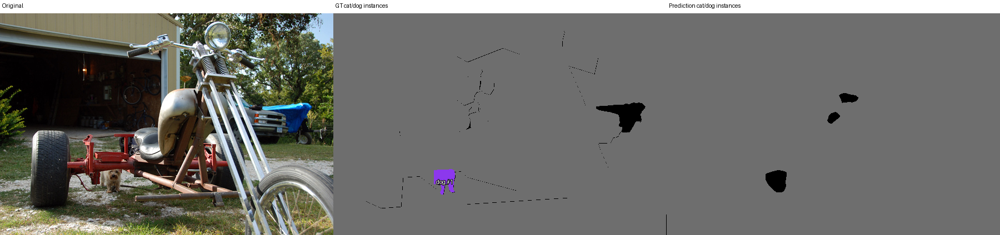

000000018833_instance_comparison.png


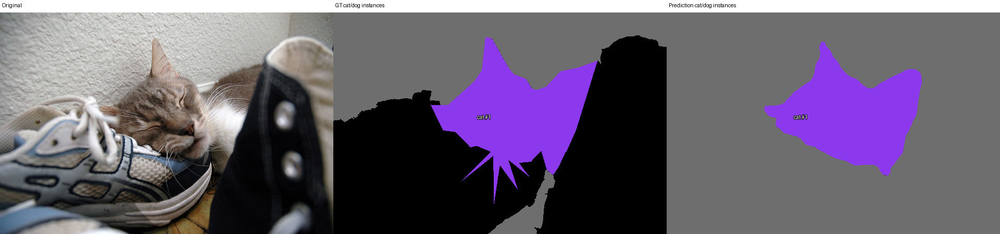

000000022192_instance_comparison.png


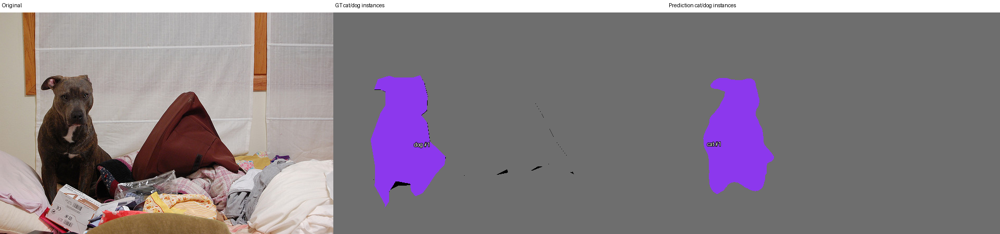

000000022892_instance_comparison.png


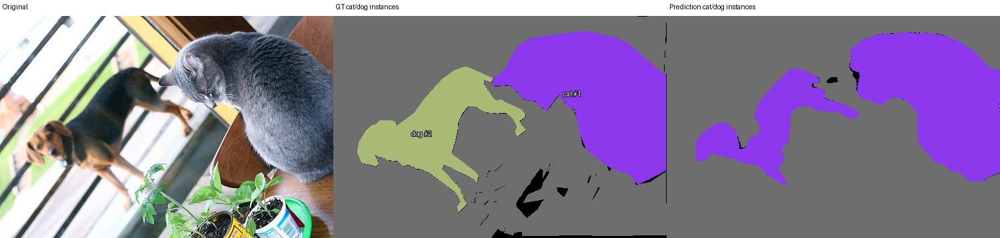

000000023272_instance_comparison.png


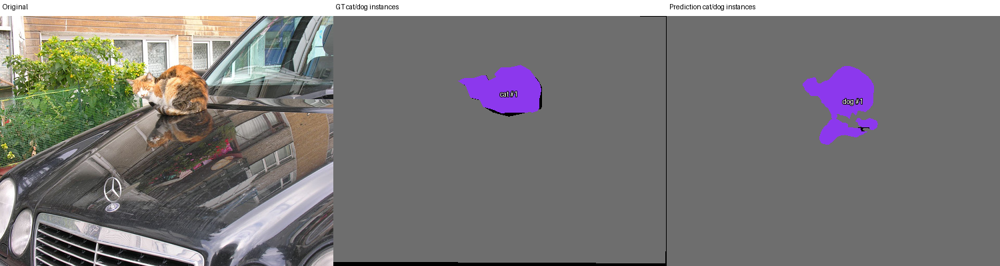

000000039769_instance_comparison.png


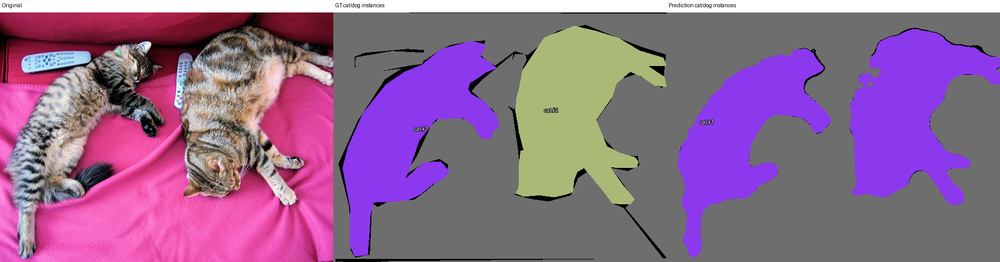

000000071226_instance_comparison.png


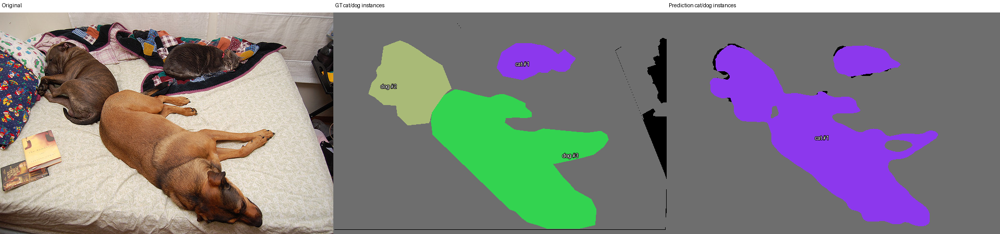

000000081766_instance_comparison.png


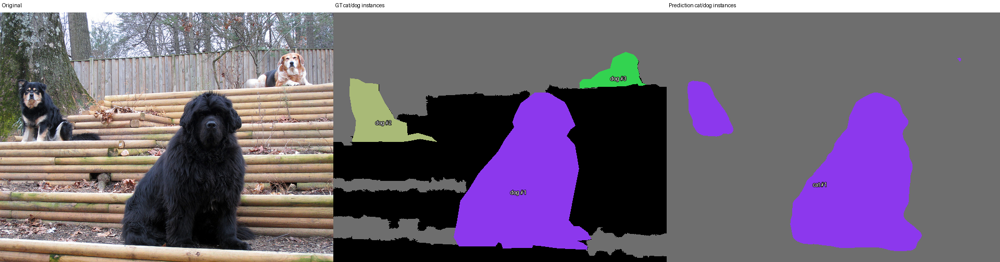

000000089271_instance_comparison.png


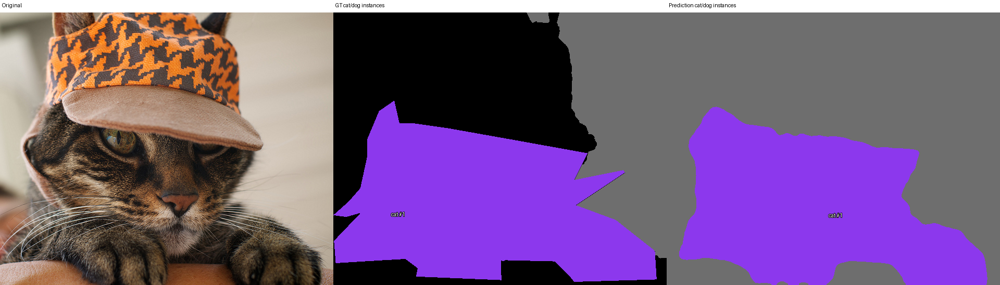

000000094336_instance_comparison.png


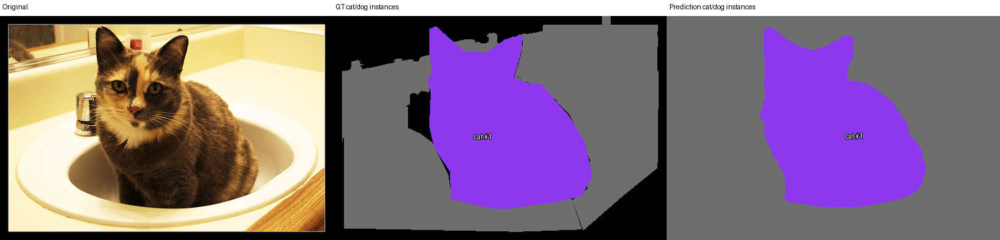

In [ ]:
# 学習後の集計CSV・fold1の独立validation比較画像を表示
import pandas as pd
display(pd.read_csv(CV_OUTPUT / "fivefold_mean_std.csv"))
display(pd.read_csv(CV_OUTPUT / "oof_pq_by_class.csv"))
for path in sorted((CV_OUTPUT / "fold_01/external_val2017/mask_low").glob("*_instance_comparison.png")):
    print(path.name)
    display(Image.open(path))


## このNotebookの動作確認
CPU / Transformers 5.16.1で、PQの完全一致・誤分類・結合・分割・IoU=0.5境界・void・同/異クラスcrowd・空予測をテスト済み。実COCO annotationの200枚を用いて160/40の非重複5分割を確認。5foldの制御と集計は学習/評価をスタブに置き換えたテストで確認。実モデルはCOCO4枚学習/2枚評価・1epochでloss/backward/optimizer/PQ/保存/再読み込み/画像出力を確認。GPUで全200枚の5fold本学習は未実行です。
